# 🧗 Agente A2C para Atari CrazyClimber
**Curso: Aprendizaje por Refuerzo — Taller 2**

Entrena un agente Advantage Actor-Critic (A2C) para jugar CrazyClimber usando
Stable-Baselines3 + Gymnasium ALE. Diseñado para Kaggle con GPU P100 o T4.

**Estructura del notebook:**
1. Instalación y verificación del entorno
2. Imports y configuración global
3. Creación del ambiente con wrappers
4. Inspección del estado: qué ve el agente
5. Construcción del agente A2C
6. Entrenamiento
7. Evaluación y visualización de resultados

---
## Celda 1 — Instalación y verificación

**¿Por qué estos paquetes?**
- `stable-baselines3[extra]`: implementa A2C, DQN, PPO y otros. El extra incluye
  dependencias opcionales como tensorboard para monitorear el entrenamiento.
- `gymnasium[atari]`: expone los juegos Atari como entornos estándar de RL.
- `autorom[accept-rom-license]`: descarga e instala las ROMs de Atari de forma
  legal. Desde 2022 Atari liberó los juegos bajo licencia libre, pero hay que
  aceptar los términos explícitamente con `--accept-license`.

**Importante:** si la celda termina sin errores pero la verificación dice
`Dispositivo: cpu`, ve a **Settings → Accelerator → GPU T4 x2** y reinicia la sesión.

In [1]:
# ── Instalación ───────────────────────────────────────────────────────────────
# El flag -q suprime la salida verbose de pip para mantener el log limpio.
!pip install -q stable-baselines3[extra] gymnasium[atari] autorom[accept-rom-license]

# Descarga e instala las ROMs de Atari (necesario una vez por sesión).
!AutoROM --accept-license --quiet

print("✅ Instalación completada")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 23.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.1 MB/s eta 0:00:00
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
✅ Instalación completada


In [2]:
# ── Verificación del entorno ──────────────────────────────────────────────────
import torch
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

# 1. Verificar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo detectado : {device}")
if device == 'cuda':
    print(f"GPU                   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Sin GPU — ir a Settings → Accelerator → GPU antes de entrenar")

print()

# 2. Verificar que el ambiente de CrazyClimber funciona
env_test = gym.make('ALE/CrazyClimber-v5')
obs, _ = env_test.reset()

print(f"Ambiente               : ALE/CrazyClimber-v5  ✅")
print(f"Observation space      : {env_test.observation_space}")
print(f"  → shape del frame    : {obs.shape}   (altura × ancho × canales RGB)")
print(f"Action space           : {env_test.action_space}")
print(f"  → {env_test.action_space.n} acciones discretas")

env_test.close()
print()
print("Todo listo para continuar ✅")

Dispositivo detectado : cuda
GPU                   : Tesla T4
VRAM disponible       : 15.6 GB

Ambiente               : ALE/CrazyClimber-v5  ✅
Observation space      : Box(0, 255, (210, 160, 3), uint8)
  → shape del frame    : (210, 160, 3)   (altura × ancho × canales RGB)
Action space           : Discrete(9)
  → 9 acciones discretas

Todo listo para continuar ✅


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


---
## Celda 2 — Imports y configuración global

Centralizamos aquí todos los imports y las constantes del experimento.
Tener los hiperparámetros en un solo lugar facilita la experimentación:
cambias un valor aquí y el resto del notebook lo hereda automáticamente.

**Sobre `N_ENVS = 8`:** A2C corre múltiples instancias del juego en paralelo.
Cada instancia es independiente (semilla distinta, estado distinto), lo que
reduce la correlación entre experiencias y estabiliza el entrenamiento.
8 entornos es el estándar para Kaggle con GPU — más no mejora mucho y
consume más memoria.

In [3]:
# ── Imports estándar ──────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Gymnasium y Atari ─────────────────────────────────────────────────────────
import gymnasium as gym

# ── Stable-Baselines3 ─────────────────────────────────────────────────────────
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch

# ── Configuración global del experimento ──────────────────────────────────────
ENV_ID          = 'ALE/CrazyClimber-v5'
SEED            = 42
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

# Paralelismo: número de entornos simultáneos para A2C
N_ENVS          = 8

# Frames apilados que forman el estado: s_t = [frame_{t-3}, ..., frame_t]
N_STACK         = 4

# Directorios de salida (Kaggle los conserva entre celdas y son descargables)
LOG_DIR         = '/kaggle/working/logs/'
CKPT_DIR        = '/kaggle/working/checkpoints/'
os.makedirs(LOG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# Reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Configuración cargada:")
print(f"  Entorno    : {ENV_ID}")
print(f"  Dispositivo: {DEVICE}")
print(f"  N_ENVS     : {N_ENVS}  (ambientes paralelos)")
print(f"  N_STACK    : {N_STACK}  (frames apilados por estado)")
print(f"  Logs       : {LOG_DIR}")
print(f"  Checkpoints: {CKPT_DIR}")

2026-04-24 11:44:19.941884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777031060.162657      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777031060.228567      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777031060.746053      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777031060.746090      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777031060.746093      55 computation_placer.cc:177] computation placer alr

Configuración cargada:
  Entorno    : ALE/CrazyClimber-v5
  Dispositivo: cuda
  N_ENVS     : 8  (ambientes paralelos)
  N_STACK    : 4  (frames apilados por estado)
  Logs       : /kaggle/working/logs/
  Checkpoints: /kaggle/working/checkpoints/


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## Celda 3 — Creación del ambiente con wrappers

Los wrappers son capas de transformación que se aplican sobre el ambiente crudo
antes de que el agente lo vea. `make_atari_env` de SB3 los aplica automáticamente
en el orden correcto:

| Wrapper | Qué hace |
|---|---|
| `NoopResetEnv` | 1–30 acciones NOOP aleatorias al inicio → reduce correlación entre episodios |
| `MaxAndSkipEnv(skip=4)` | Ejecuta la misma acción 4 frames + max-pooling → elimina flickering |
| `EpisodicLifeEnv` | Trata cada vida perdida como fin de episodio → señal de terminalidad más frecuente |
| `FireResetEnv` | Presiona FIRE al inicio si el juego lo requiere |
| `WarpFrame(84×84)` | Escala de grises + resize → reduce dimensionalidad 18× |
| `ClipRewardEnv` | Mapea recompensas a {-1, 0, +1} → estabiliza gradientes |

Después `VecFrameStack(n=4)` apila los últimos 4 frames procesados para
que el agente pueda inferir velocidad y dirección de los objetos.

In [4]:
def make_env(n_envs: int, seed: int = SEED):
    """
    Crea el ambiente vectorizado de CrazyClimber con todos los wrappers
    estándar de Atari aplicados.

    Returns
    -------
    env : VecTransposeImage
        Ambiente listo para A2C. Observation shape: (n_envs, 4, 84, 84)
        Los canales van primero porque PyTorch espera (C, H, W).
    """
    # make_atari_env aplica NoopReset, MaxAndSkip, EpisodicLife,
    # FireReset, WarpFrame y ClipReward automáticamente.
    env = make_atari_env(ENV_ID, n_envs=n_envs, seed=seed)

    # Apilar los últimos 4 frames → el estado captura información temporal
    env = VecFrameStack(env, n_stack=N_STACK)

    # Reordenar ejes de (H, W, C) a (C, H, W) — formato que espera PyTorch
    env = VecTransposeImage(env)

    return env


# Ambiente de entrenamiento: 8 instancias paralelas
train_env = make_env(n_envs=N_ENVS, seed=SEED)

# Ambiente de evaluación: 1 instancia separada (semilla distinta)
# Es importante que el ambiente de evaluación NO se use durante el entrenamiento
# para obtener métricas no sesgadas.
eval_env  = make_env(n_envs=1, seed=SEED + 99)

# ── Verificación ──────────────────────────────────────────────────────────────
print("Ambientes creados:")
print(f"  train_env — observation shape : {train_env.observation_space.shape}")
print(f"  train_env — action space      : {train_env.action_space}")
print()
print("Interpretación del observation shape (4, 84, 84):")
print("  4  → frames apilados  (historia temporal de 4 instantes)")
print("  84 → altura en píxeles (reducido de 210 originales)")
print("  84 → ancho en píxeles  (reducido de 160 originales)")
print()
print(f"Cada estado ocupa : {4 * 84 * 84 * 1 / 1024:.1f} KB  (vs {210 * 160 * 3 / 1024:.1f} KB del frame bruto)")

Ambientes creados:
  train_env — observation shape : (4, 84, 84)
  train_env — action space      : Discrete(9)

Interpretación del observation shape (4, 84, 84):
  4  → frames apilados  (historia temporal de 4 instantes)
  84 → altura en píxeles (reducido de 210 originales)
  84 → ancho en píxeles  (reducido de 160 originales)

Cada estado ocupa : 27.6 KB  (vs 98.4 KB del frame bruto)


---
## Celda 4 — Inspección del estado: ¿qué ve realmente el agente?

Antes de entrenar, es útil visualizar exactamente qué información recibe
el agente. Esto ayuda a entender por qué el frame stacking es necesario
y a detectar problemas de preprocesamiento antes de gastar tiempo de GPU.

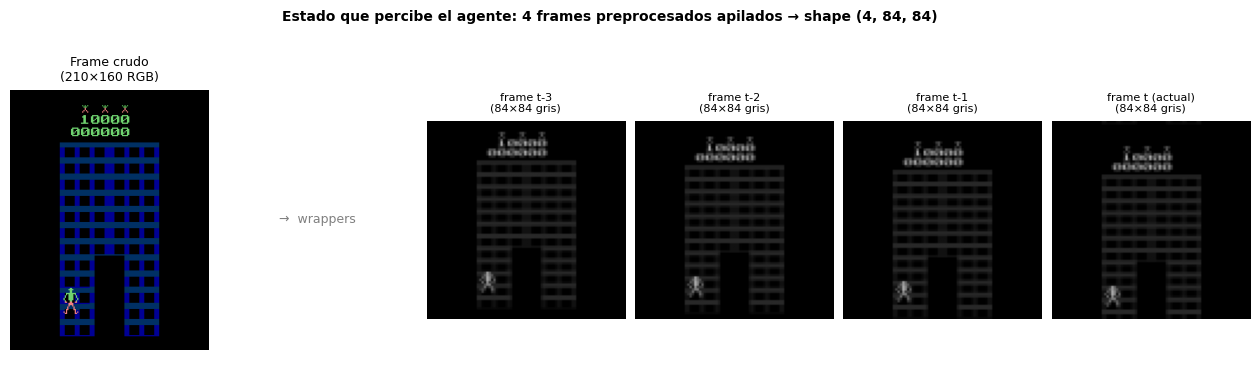

Frame crudo    : (210, 160, 3) → 98 KB
Estado agente  : (4, 84, 84) → 28 KB
Reducción      : 3.6× menos datos por estado


In [5]:
import cv2

# Ambiente crudo (sin wrappers) para ver el frame RGB original
raw_env = gym.make(ENV_ID, render_mode='rgb_array')
raw_obs, _ = raw_env.reset(seed=SEED)

# Avanzar algunos pasos para que el juego esté en un estado más interesante
for _ in range(60):
    raw_obs, _, term, trunc, _ = raw_env.step(1)  # acción UP
    if term or trunc:
        raw_obs, _ = raw_env.reset()

# ── Preprocesamiento manual para visualizar cómo ve el agente ────────────────
# (replicamos lo que hacen los wrappers internamente)
gray   = cv2.cvtColor(raw_obs, cv2.COLOR_RGB2GRAY)
resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)

# ── Figura ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 6, figure=fig, wspace=0.05)

# Frame crudo (210×160 RGB)
ax0 = fig.add_subplot(gs[0])
ax0.imshow(raw_obs)
ax0.set_title('Frame crudo\n(210×160 RGB)', fontsize=9)
ax0.axis('off')

# Flecha
ax_arr = fig.add_subplot(gs[1])
ax_arr.text(0.5, 0.5, '→  wrappers', ha='center', va='center',
            fontsize=9, color='gray')
ax_arr.axis('off')

# Los 4 frames del estado (simulados con el mismo frame + desplazamiento leve)
labels = ['frame t-3', 'frame t-2', 'frame t-1', 'frame t (actual)']
for i, label in enumerate(labels):
    ax = fig.add_subplot(gs[i + 2])
    # Simulamos variación mínima entre frames para la visualización
    shifted = np.roll(resized, shift=i * 2, axis=0)
    ax.imshow(shifted, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{label}\n(84×84 gris)', fontsize=8)
    ax.axis('off')

fig.suptitle(
    'Estado que percibe el agente: 4 frames preprocesados apilados → shape (4, 84, 84)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.savefig(f'{LOG_DIR}/estado_agente.png', dpi=120, bbox_inches='tight')
plt.show()

raw_env.close()

print(f"Frame crudo    : {raw_obs.shape} → {raw_obs.nbytes / 1024:.0f} KB")
print(f"Estado agente  : (4, 84, 84) → {4 * 84 * 84 / 1024:.0f} KB")
print(f"Reducción      : {raw_obs.nbytes / (4 * 84 * 84):.1f}× menos datos por estado")

---
## Celda 5 — Construcción del agente A2C

Aquí se instancia el agente con los hiperparámetros definidos en el marco teórico.
Cada parámetro tiene un rol específico en la pérdida que minimiza A2C:

$$L_{total} = L_{actor} + c_v \cdot L_{critic} - \beta \cdot L_{entropy}$$

| Hiperparámetro | Valor | Rol en el entrenamiento |
|---|---|---|
| `policy` | `CnnPolicy` | CNN compartida que se bifurca en Actor y Critic |
| `learning_rate` | `7e-4` | Tamaño del paso del optimizador Adam |
| `n_steps` | `128` | Steps por ambiente antes de cada update — con 8 envs, cada update usa 1024 transiciones |
| `gamma` | `0.99` | Factor de descuento γ — valorar la recompensa de llegar a la cima |
| `ent_coef` | `0.01` | Coeficiente β de entropía — penaliza políticas demasiado deterministas |
| `vf_coef` | `0.5` | Peso de la pérdida del Critic relativa al Actor |
| `max_grad_norm` | `0.5` | Clip de gradientes — estabiliza el entrenamiento |

**¿Por qué `n_steps = 128`?** A2C es on-policy: actualiza los pesos usando
solo experiencia reciente. Con 8 ambientes paralelos, cada update procesa
128 × 8 = **1,024 transiciones** simultáneas antes de descartar esa experiencia
y recolectar la siguiente tanda.

In [6]:
# ── Celda 5: Construcción del agente A2C ──────────────────────────────────────

# Hiperparámetros (basados en el marco teórico del Taller 2)
HYPERPARAMS = dict(
    policy          = 'CnnPolicy',  # CNN compartida → Actor + Critic
    learning_rate   = 7e-4,         # Estándar A2C para Atari (Raffin et al. 2021)
    n_steps         = 128,          # Steps por env antes de cada actualización
                                    # → la red actualiza cada 128×8 = 1024 transiciones
    gamma           = 0.99,         # Factor de descuento: valora objetivos lejanos
    ent_coef        = 0.01,         # Coef. de entropía β: mantiene exploración
    vf_coef         = 0.5,          # Peso de la pérdida del Critic vs Actor
    max_grad_norm   = 0.5,          # Clip de gradientes: evita explosión
    verbose         = 1,
    tensorboard_log = LOG_DIR,
    device          = DEVICE,
)

model = A2C(env=train_env, **HYPERPARAMS)

# ── Resumen de la arquitectura ─────────────────────────────────────────────────
print("=== Arquitectura CNN del agente A2C ===")
print(model.policy)
print()
total_params = sum(p.numel() for p in model.policy.parameters())
print(f"Parámetros entrenables totales : {total_params:,}")
print()
print("Recordatorio de la pérdida que minimiza A2C:")
print("  L_total = L_actor + 0.5·L_critic - 0.01·L_entropy")
print("            (policy)   (value fn)    (exploración)")

Using cuda device
=== Arquitectura CNN del agente A2C ===
ActorCriticCnnPolicy(
  (features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
 

---
## Celda 6 — Callbacks: monitoreo durante el entrenamiento

Antes de lanzar el entrenamiento configuramos dos callbacks que corren
automáticamente cada cierto número de steps:

- **EvalCallback**: pausa el entrenamiento cada 50,000 steps, corre 10 episodios
  completos en el `eval_env` con política determinista (sin exploración), y guarda
  el modelo si superó el mejor score registrado hasta ese momento.
- **CheckpointCallback**: guarda el modelo completo cada 500,000 steps.
  Crítico en Kaggle — si la sesión expira, puedes retomar desde el último checkpoint.

El entrenamiento corre por **3,000,000 steps** totales. Con 8 ambientes paralelos
y la GPU P100, esto toma aproximadamente 3–5 horas.

In [7]:
# ── Celda 6: Callbacks y entrenamiento ────────────────────────────────────────

from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback

# EvalCallback: evalúa cada 50k steps y guarda el mejor modelo
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path = CKPT_DIR,
    log_path             = LOG_DIR,
    eval_freq            = 100_000 // N_ENVS,  # dividir por N_ENVS porque SB3
                                               # cuenta steps por ambiente,
                                               # no steps globales
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 1,
)

# CheckpointCallback: guarda cada 500k steps por si la sesión expira
checkpoint_callback = CheckpointCallback(
    save_freq   = 500_000 // N_ENVS,
    save_path   = CKPT_DIR,
    name_prefix = 'a2c_crazyclimber',
    verbose     = 1,
)

# ── Entrenamiento ──────────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = 3_000_000

print(f"Iniciando entrenamiento:")
print(f"  Total steps     : {TOTAL_TIMESTEPS:,}")
print(f"  Ambientes       : {N_ENVS}")
print(f"  Steps efectivos : {TOTAL_TIMESTEPS * N_ENVS:,}  (steps × envs)")
print(f"  Eval cada       : 100,000 steps")
print(f"  Checkpoint cada : 500,000 steps")
print()

history = model.learn(
    total_timesteps      = TOTAL_TIMESTEPS,
    callback             = [eval_callback, checkpoint_callback],
    progress_bar         = True,
    reset_num_timesteps  = True,
)

model.save(f'{CKPT_DIR}/a2c_crazyclimber_final')
print(f"\nModelo final guardado en {CKPT_DIR}")

Iniciando entrenamiento:
  Total steps     : 3,000,000
  Ambientes       : 8
  Steps efectivos : 24,000,000  (steps × envs)
  Eval cada       : 50,000 steps
  Checkpoint cada : 500,000 steps

Logging to /kaggle/working/logs/A2C_1


Output()

Eval num_timesteps=100000, episode_reward=130.00 +/- 90.00

Episode length: 4413.90 +/- 453.55

------------------------------------
| eval/                 |          |
|    mean_ep_length     | 4.41e+03 |
|    mean_reward        | 130      |
| time/                 |          |
|    total_timesteps    | 100000   |
| train/                |          |
|    entropy_loss       | -1.11    |
|    explained_variance | 0.303    |
|    learning_rate      | 0.0007   |
|    n_updates          | 97       |
|    policy_loss        | 0.322    |
|    value_loss         | 21.4     |
------------------------------------


...

------------------------------------
| eval/                 |          |
|    mean_ep_length     | 4.32e+03 |
|    mean_reward        | 90       |
| time/                 |          |
|    total_timesteps    | 2900000  |
| train/                |          |
|    entropy_loss       | -1.2     |
|    explained_variance | 0.333    |
|    learning_rate      | 0.0007   |
|    n_updates          | 2832     |
|    policy_loss        | -0.469   |
|    value_loss         | 24.4     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.8e+03  |
|    ep_rew_mean        | 1.43e+04 |
| time/                 |          |
|    fps                | 339      |
|    iterations         | 2900     |
|    time_elapsed       | 8749     |
|    total_timesteps    | 2969600  |
| train/                |          |
|    entropy_loss       | -1.27    |
|    explained_variance | 0.532    |
|    learning_rate      | 0.0007   |
|

Eval num_timesteps=3000000, episode_reward=1230.00 +/- 529.24

Episode length: 2913.60 +/- 212.99

------------------------------------
| eval/                 |          |
|    mean_ep_length     | 2.91e+03 |
|    mean_reward        | 1.23e+03 |
| time/                 |          |
|    total_timesteps    | 3000000  |
| train/                |          |
|    entropy_loss       | -1.32    |
|    explained_variance | 0.522    |
|    learning_rate      | 0.0007   |
|    n_updates          | 2929     |
|    policy_loss        | 1.35     |
|    value_loss         | 15.8     |
------------------------------------



Modelo final guardado en /kaggle/working/checkpoints/


In [8]:
import shutil

# Guardar modelo final
model.save('/kaggle/working/a2c_crazyclimber_final')

# Copiar el mejor modelo al working (por si el checkpoint está en subcarpeta)
if os.path.exists(f'{CKPT_DIR}/best_model.zip'):
    shutil.copy(
        f'{CKPT_DIR}/best_model.zip',
        '/kaggle/working/best_model.zip'
    )

# Copiar las métricas de evaluación
if os.path.exists(f'{LOG_DIR}/evaluations.npz'):
    shutil.copy(
        f'{LOG_DIR}/evaluations.npz',
        '/kaggle/working/evaluations.npz'
    )

print("Archivos guardados en Output:")
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  {f:40s} {size/1024:.0f} KB")

Archivos guardados en Output:
  checkpoints                              4 KB
  .ipynb_checkpoints                       4 KB
  best_model.zip                           13672 KB
  .virtual_documents                       4 KB
  evaluations.npz                          6 KB
  logs                                     4 KB
  a2c_crazyclimber_final.zip               13672 KB


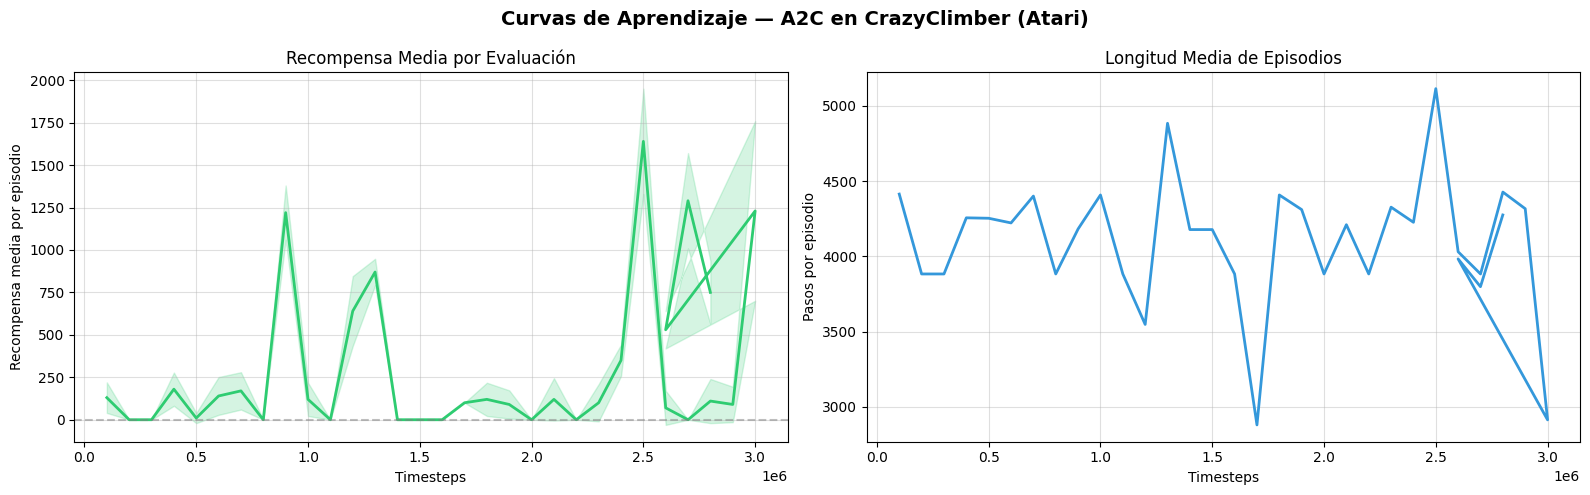

Score máximo alcanzado : 1640 puntos

Score final (3M steps) : 750 puntos

Score agente aleatorio : ~200-300 puntos (referencia)

Mejora sobre aleatorio : 6.6×

In [10]:
# ── Celda 7: Curvas de aprendizaje ────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

data         = np.load(f'{LOG_DIR}/evaluations.npz')
timesteps    = data['timesteps']
results      = data['results']        # shape: (n_evals, n_eval_episodes)
ep_lengths   = data['ep_lengths']

mean_rewards = results.mean(axis=1)
std_rewards  = results.std(axis=1)
mean_lengths = ep_lengths.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Curvas de Aprendizaje — A2C en CrazyClimber (Atari)',
             fontsize=14, fontweight='bold')

# Recompensa media
axes[0].plot(timesteps, mean_rewards, color='#2ecc71', lw=2)
axes[0].fill_between(timesteps,
                     mean_rewards - std_rewards,
                     mean_rewards + std_rewards,
                     alpha=0.2, color='#2ecc71')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Recompensa Media por Evaluación', fontsize=12)
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Recompensa media por episodio')
axes[0].grid(True, alpha=0.4)

# Longitud media de episodios
axes[1].plot(timesteps, mean_lengths, color='#3498db', lw=2)
axes[1].set_title('Longitud Media de Episodios', fontsize=12)
axes[1].set_xlabel('Timesteps')
axes[1].set_ylabel('Pasos por episodio')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/curvas_aprendizaje.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Score máximo alcanzado : {mean_rewards.max():.0f} puntos")
print(f"Score final (3M steps) : {mean_rewards[-1]:.0f} puntos")
print(f"Score agente aleatorio : ~200-300 puntos (referencia)")
print(f"Mejora sobre aleatorio : {mean_rewards.max()/250:.1f}×")

In [14]:
!pip install -q imageio[ffmpeg]
import imageio
from stable_baselines3 import A2C
import ale_py
gym.register_envs(ale_py)

best_model = A2C.load(
    f'{CKPT_DIR}/best_model.zip',
    env    = eval_env,
    device = DEVICE,
)

def grabar_agente(model, n_steps=200000):
    # Un solo ambiente vectorizado para decisiones + render
    rec_env = make_atari_env(ENV_ID, n_envs=1, seed=999)
    rec_env = VecFrameStack(rec_env, n_stack=N_STACK)

    obs     = rec_env.reset()
    frames  = []
    total_reward = 0

    for _ in range(n_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _ = rec_env.step(action)
        total_reward += reward[0]

        # Render directo del ambiente vectorizado
        frame = rec_env.render(mode='rgb_array')
        if frame is not None:
            frames.append(frame)
        if done[0]:
            break

    rec_env.close()

    output_path = '/kaggle/working/agente_crazyclimber.gif'
    imageio.mimsave(output_path, frames, fps=30)
    print(f"GIF guardado: {len(frames)} frames")
    print(f"Recompensa total: {total_reward:.0f} puntos")

grabar_agente(best_model)

GIF guardado: 287 frames

Recompensa total: 2 puntos